 <h1 align="center"><font size="7">Graph Networks</font></h1>


<h1 align="center"><font size="5">Training Cora Dataset for Node Prediction</font></h1>

<div class="alert alert-info"><p>
This is the second of a series of notebooks for graph node classification and link prediction. In this notebook we will show how to train graph networks for node classification on the Cora Dataset from the Planetoid series. Following training and testing, model explainability will be tested.
</p></div>

> **Note:** This notebook only trains and evaluates the `GCN` model (the argparse default). The other architectures (`GATV2`, `GConv`, `SAGE`) were run separately from the command line, e.g.:
> ```
> uv run python src/node_classification/planetoid_node_classification.py --model GATV2
> ```

### Table of Contents
---

1. [Training & Test](#training-and-test)
2. [Training Visualizations](#training-viz)
3. [Load Dataset](#load-dataset)
4. [Embeddings - Inference ](#embeddings)
5. [Explainability](#xai)


<a id="training-and-test"></a>

## 1. Training & Test

In [1]:
import os
import argparse

# numeric
import pandas as pd
from IPython.display import display

from src.common.paths import get_project_root
from src.node_classification.planetoid_node_classification import main


In [2]:
parser = argparse.ArgumentParser(description='Node classification')

In [3]:
parser.add_argument('--dataset', type=str, default="Cora",
                    help="Dataset name: Cora, CiteSeer, PubMed")
parser.add_argument('--log_steps', type=int, default=10)
parser.add_argument("--model", choices=["GCN", "GATV2", "GConv", "SAGE"],
                    default="GCN")
parser.add_argument('--num_layers', type=int, default=2)
parser.add_argument('--hidden_channels', type=int, default=16)
parser.add_argument('--dropout', type=float, default=0.5)
parser.add_argument('--heads', type=int, default=8)
parser.add_argument('--lr', type=float, default=0.01)
parser.add_argument('--weight_decay', type=float, default=5e-4)
parser.add_argument('--epochs', type=int, default=200)
parser.add_argument('--seeds', type=int, nargs='+', default=[0, 1, 2, 3, 4])
parser.add_argument('--early_stop', type=int, default=12)
args, unknown = parser.parse_known_args()
print(args)

Namespace(dataset='Cora', log_steps=10, model='GCN', num_layers=2, hidden_channels=16, dropout=0.5, heads=8, lr=0.01, weight_decay=0.0005, epochs=200, seeds=[0, 1, 2, 3, 4], early_stop=12)


In [4]:
training_summary, history_df = main(args)

Running GCN on Cora dataset
Device: mps  Features: 1433  Classes: 7

Seed: 0  |  epoch 010  |  train_loss=1.5938  |  train_acc=0.4500  |  val_loss=1.5823  |  val_acc=0.7520  |  
Seed: 0  |  epoch 020  |  train_loss=1.0562  |  train_acc=0.5929  |  val_loss=0.9850  |  val_acc=0.7800  |  
Seed: 0  |  epoch 030  |  train_loss=0.6833  |  train_acc=0.7357  |  val_loss=0.7920  |  val_acc=0.7920  |  
Seed: 0  |  epoch 040  |  train_loss=0.5410  |  train_acc=0.8143  |  val_loss=0.7859  |  val_acc=0.7720  |  
Seed: 0  |  epoch 050  |  train_loss=0.4409  |  train_acc=0.8286  |  val_loss=0.8115  |  val_acc=0.7760  |  
Early stopping at epoch 55 (no val_loss improvement for 12 epochs)
Completed runs with seed: 0  | best_epoch=43  |  val_loss=0.7720  |  test_acc=0.7990
Seed: 1  |  epoch 010  |  train_loss=1.6414  |  train_acc=0.4000  |  val_loss=1.6849  |  val_acc=0.5500  |  
Seed: 1  |  epoch 020  |  train_loss=1.0861  |  train_acc=0.6643  |  val_loss=1.2037  |  val_acc=0.7080  |  
Seed: 1  |  epoc

In [5]:
print(training_summary)

                            mean       std    ci_low   ci_high
Test loss               0.719306  0.048085  0.659600  0.779012
Test acc                0.791000  0.015379  0.771905  0.810095
Test precision          0.766809  0.016962  0.745749  0.787870
Test recall             0.805836  0.013091  0.789581  0.822091
Test f1                 0.781749  0.015924  0.761977  0.801521
Test balanced_accuracy  0.805836  0.013091  0.789581  0.822091
Test brier              0.158776  0.008087  0.148735  0.168817
Test roc_auc            0.952492  0.009746  0.940391  0.964592
Test avg_precision      0.856501  0.014819  0.838100  0.874901
Test ece                0.052595  0.037321  0.006255  0.098935


In [6]:
root_dir = get_project_root()

In [7]:
# Review the results per seed
results_per_seed = pd.read_csv(root_dir / "outputs" / "metrics" / "cora" / "gcn_results.csv")
print(results_per_seed)

   seed  best_epoch  val_loss      loss    acc  precision    recall        f1  \
0     0          43  0.772041  0.659989  0.799   0.777755  0.815495  0.792524   
1     1          48  0.782205  0.773649  0.772   0.745376  0.792129  0.762751   
2     2          36  0.791846  0.684080  0.810   0.784623  0.817276  0.798267   
3     3          50  0.758084  0.720325  0.795   0.773809  0.813233  0.788324   
4     4          58  0.849364  0.758489  0.779   0.752482  0.791046  0.766878   

   balanced_accuracy     brier   roc_auc  avg_precision       ece  
0           0.815495  0.150325  0.962137       0.871005  0.046033  
1           0.792129  0.171821  0.940624       0.837236  0.034268  
2           0.817276  0.154584  0.962952       0.871878  0.117085  
3           0.813233  0.157496  0.947216       0.849754  0.043964  
4           0.791046  0.159653  0.949529       0.852631  0.021625  


<a id="training-viz"></a>
## 2. Training Visualizations

In [8]:
from src.common.datasets import load_planetoid
from src.node_classification.node_models import GCN
from src.common.utils import get_device, load_checkpoint
from src.common.training_visualisations import (plot_metric_curves, compute_embedding,
                                                plot_embeddings_3d, get_embeddings)
from src.common.evaluation_metrics import EmbeddingMetrics

In [9]:
# Create figures directory
figures_dir = root_dir / "outputs" / "figures"
cora_figs = figures_dir / "cora"
os.makedirs(cora_figs, exist_ok=True)

In [10]:
plot_metric_curves(history_df, cora_figs, name="gcn",
                   metrics=("loss", "acc", "f1"))

alt.Chart(...)

<a id="load-dataset"></a>
## 3. Load Dataset for Inference

In [11]:
# Get the path to the data and checkpoint directory
data_path = root_dir / "data"
checkpoint_dir = root_dir / "outputs" / "checkpoints" / "cora"


In [12]:
# Load the dataset
dataset, data = load_planetoid(path=data_path, dataset_name="Cora")
device = get_device()
data = data.to(device)

In [ ]:
best_seed = int(results_per_seed.loc[results_per_seed["val_loss"].idxmin(), "seed"])
print(f"Best seed by validation loss: {best_seed}")

Best seed by validation loss: 3


In [14]:
# Instantiate the model and load the best checkpoint
model = GCN(num_layers=args.num_layers, in_feat=dataset.num_features,
            hid_feat=args.hidden_channels, num_classes=dataset.num_classes,
            dropout=args.dropout)
best_gcn = load_checkpoint(model, checkpoint_dir / f"cora_gcn_{best_seed}_best.pth",
                           device=device, state_key="model")

<a id="embeddings"></a>
## 4. Embeddings - Inference

In [15]:
# mapping numerical labels to types of papers on the Dataset
label_dict = {
    0: "Theory",
    1: "Reinforcement Learning",
    2: "Genetic Algorithms",
    3: "Neural Networks",
    4: "Probabilistic Methods",
    5: "Case Based",
    6: "Rule Learning"}

In [16]:
# Create the 3D embeddings for visualization
best_embedding_3d = compute_embedding(
    best_gcn,
    data.x.to(device),
    data.edge_index.to(device),
    method="tsne", n_components=3)

chart = plot_embeddings_3d(
    embedding=best_embedding_3d,
    labels=data.y, label_map=label_dict,
    fig_dir=cora_figs,
    name='gcn_tsne',
    title="Cora node embeddings",
)

In [17]:
chart

In [18]:
# Get the embeddings for computation of silhouette scores
embeddings = get_embeddings(best_gcn.to(device), data.x.to(device), data.edge_index.to(device))

In [19]:
# Silhouette score on test set
test_sil = EmbeddingMetrics.compute(
    embeddings[data.test_mask], 
    labels=data.y[data.test_mask],
    metric="cosine")

print(f"Silhouette (test nodes): {test_sil.silhouette:.4f}")


Silhouette (test nodes): 0.3796


In [20]:
 # Silhouette score on all nodes
all_data_sil = EmbeddingMetrics.compute(
    embeddings=embeddings,
    labels=data.y,
    metric="cosine",)

print(
    f"Silhouette score for all data: "
    f"{all_data_sil.silhouette:.4f}"
)

Silhouette score for all data: 0.4117


<a id="xai"></a>
## 5. Explainability


---
#### Methodology

---

This section evaluates the trained GCN's predictions using [GNNExplainer](https://arxiv.org/abs/1903.03894). For each sampled test node we generate an explanatory subgraph and feature-importance mask, then score how well that explanation reflects the model's actual reasoning using the fidelity, unfaithfulness, and characterization metrics described below.

```mermaid
flowchart TD
    A[Create the explainer] --> B[Evaluate the explanations]
    B --> C[Get the average top-k feature importance]
    C --> D[Find test nodes]
    D --> E[Randomly sample test nodes up to max_nodes]
    E --> F[Explain each sampled node]
    F --> G["Store explanations + fidelity/unfaithfulness +<br/>characterization + confidence"]
    G --> H[Overall XAI evaluation]
    H --> I[From the same sample, select:]
    I --> J[High-confidence correct]
    I --> K[Low-confidence correct]
    I --> L[High-confidence incorrect]
```

---
#### Understanding the fidelity metrics

---

**Fidelity** measures how much the explanatory subgraph actually contributes to
the model's prediction. It has two directions:

- **Fidelity+** removes the explanatory subgraph from the full graph and measures
  how much the prediction changes. If the flagged part was truly important,
  removing it should hurt the prediction, so **higher Fidelity+ is better**.
- **Fidelity−** gives the model *only* the explanatory subgraph and measures how
  much the prediction changes. If that part is sufficient on its own, the
  prediction should be preserved, so **lower Fidelity− is better**.

Together they check both sides of a good explanation: the important part is
*necessary* (removing it hurts) and *sufficient* (keeping only it preserves the
prediction). The fidelity scores capture how well the explanation reproduces the
GNN's logic.

**Unfaithfulness** evaluates how far an explanation diverges from the underlying
GNN predictor, by comparing the model's output on the full input against its
output on the masked (explanation-only) input. **Lower is better**: a faithful
explanation induces nearly the same prediction distribution as the full model.

**Characterization score** (as defined in PyG) combines the two fidelity
directions into a single number, using a harmonic-style balance between high
Fidelity+ and low Fidelity−. It is high only when *both* conditions hold, so it
penalises an explanation that is strong in one direction but weak in the other.

### Reading the scores

A good explanation looks like this:

> Removing the important part hurts the prediction (**high Fidelity+**)
> **and** keeping only the important part preserves it (**low Fidelity−**)
> → **high characterization score**

Two contrasting examples:

| | Fidelity+ | Fidelity− | Meaning |
|---|---|---|---|
| Strong explanation | 0.90 | 0.10 | important part is both necessary and sufficient → characterization high |
| Weak explanation | 0.20 | 0.60 | removing it barely matters and it is not sufficient alone → characterization low |

In [21]:
from src.common import explainability as xai

In [22]:
# Instantiate the explainer
explainer = xai.create_explainer(model=best_gcn.to(device),
                                 num_features=dataset.num_features,
                                 method="gnn_explainer", epochs=100)

In [23]:
# If no sample_indices are given, the evaluation is on the test set
sample = int(data.test_mask.sum())
results, metrics_summary, feat_importance, sampled_nodes, explanations = xai.eval_explanations(
        explainer=explainer,
        data=data,
        max_samples=sample,
        seed=123,)


In [24]:
# Print the metrics summary
print(metrics_summary)

                      mean       std  valid  invalid
fidelity_plus     0.679000  0.467094   1000        0
fidelity_minus    0.000000  0.000000   1000        0
unfaithfulness    0.248091  0.121504   1000        0
characterization  0.679000  0.467094   1000        0


In [25]:
# Print the top-k feature importance
print(feat_importance[:20])

    feature  importance
0      1263    0.021252
1      1177    0.018859
2        19    0.014899
3      1209    0.012692
4       507    0.012516
5       774    0.011866
6      1075    0.008883
7      1328    0.007208
8      1381    0.006808
9       495    0.006778
10      132    0.005923
11     1301    0.005865
12     1071    0.005657
13     1131    0.005140
14     1352    0.005008
15     1230    0.004978
16      540    0.004897
17     1132    0.004768
18      619    0.004755
19      725    0.004269


In [26]:
# Visualize the aggregated feature importance
xai.plot_aggregate_feature_importance(feat_importance,
                                      top_k=10)

alt.Chart(...)

### 5.1 Visualize some examples from the initial node samples

In [27]:
# Get 3 samples from the sample_nodes
examples = xai.select_xai_examples(results, n=3, seed=123)

# display(pd.DataFrame(examples).T)

In [28]:
for name, group in examples.items():
    print(f"\n{name}")
    display(
        group[
            [
                "node",
                "true_class",
                "predicted_class",
                "confidence",
            ]
        ]
    )


High-confidence correct


,node,true_class,predicted_class,confidence
749,2457,6,6,0.977092
128,1836,6,6,0.999710
372,2080,1,1,0.989467



Low-confidence correct


,node,true_class,predicted_class,confidence
814,2522,2,2,0.585047
140,1848,0,0,0.696002
408,2116,0,0,0.661738



High-confidence incorrect


,node,true_class,predicted_class,confidence
859,2567,3,0,0.801199
647,2355,4,0,0.943048
555,2263,4,0,0.904747



High-confidence correct
Node: 2457
True class: Rule Learning
Predicted class: Rule Learning
Confidence: 0.977


alt.Chart(...)

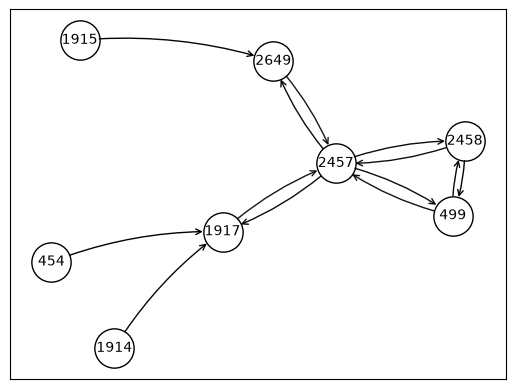


High-confidence correct
Node: 1836
True class: Rule Learning
Predicted class: Rule Learning
Confidence: 1.000


alt.Chart(...)

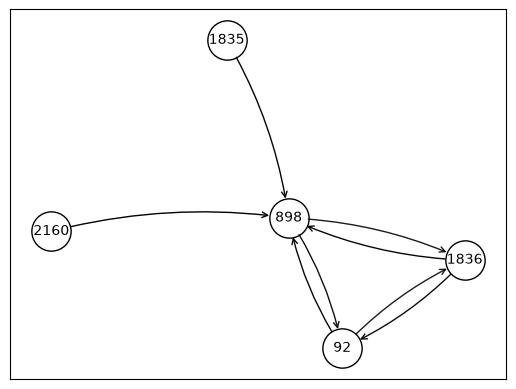


High-confidence correct
Node: 2080
True class: Reinforcement Learning
Predicted class: Reinforcement Learning
Confidence: 0.989


alt.Chart(...)

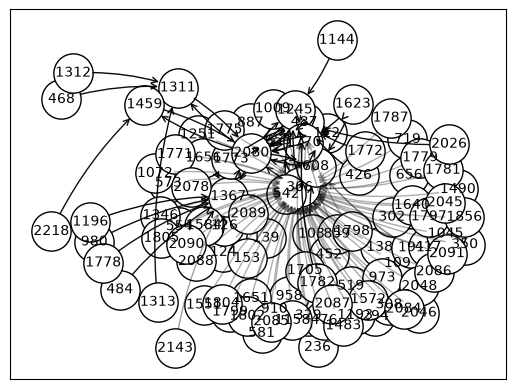


Low-confidence correct
Node: 2522
True class: Genetic Algorithms
Predicted class: Genetic Algorithms
Confidence: 0.585


alt.Chart(...)

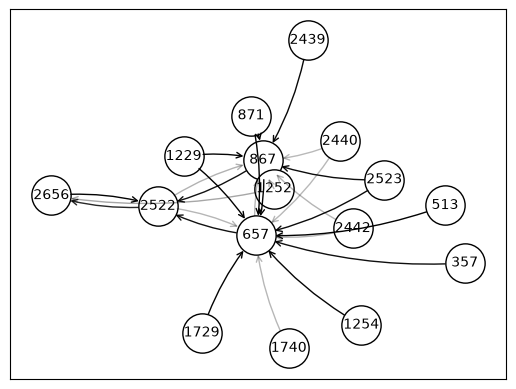


Low-confidence correct
Node: 1848
True class: Theory
Predicted class: Theory
Confidence: 0.696


alt.Chart(...)

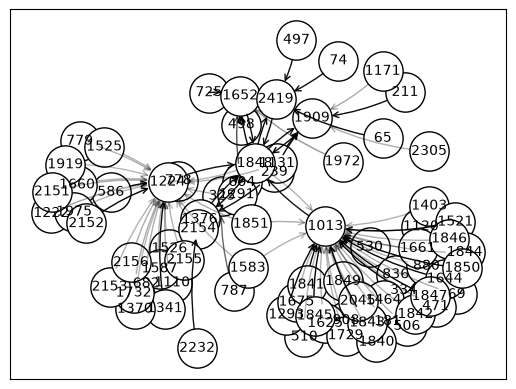


Low-confidence correct
Node: 2116
True class: Theory
Predicted class: Theory
Confidence: 0.662


alt.Chart(...)

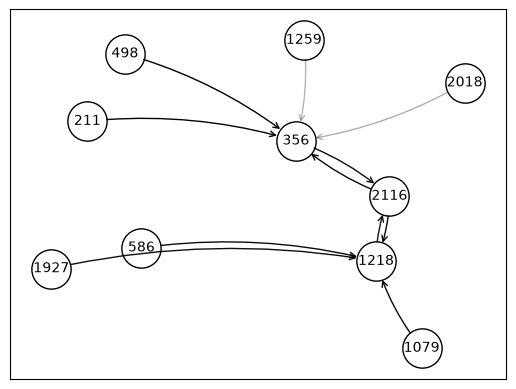


High-confidence incorrect
Node: 2567
True class: Neural Networks
Predicted class: Theory
Confidence: 0.801


alt.Chart(...)

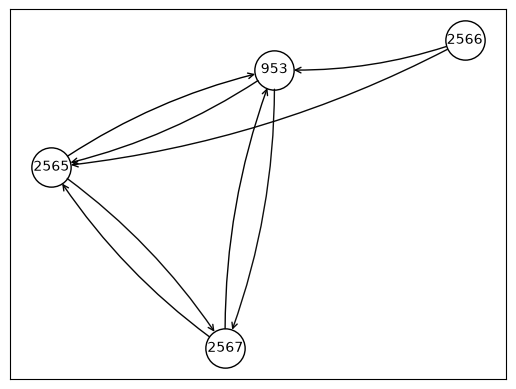


High-confidence incorrect
Node: 2355
True class: Probabilistic Methods
Predicted class: Theory
Confidence: 0.943


alt.Chart(...)

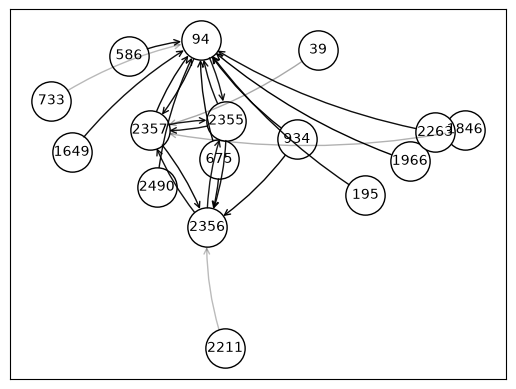


High-confidence incorrect
Node: 2263
True class: Probabilistic Methods
Predicted class: Theory
Confidence: 0.905


alt.Chart(...)

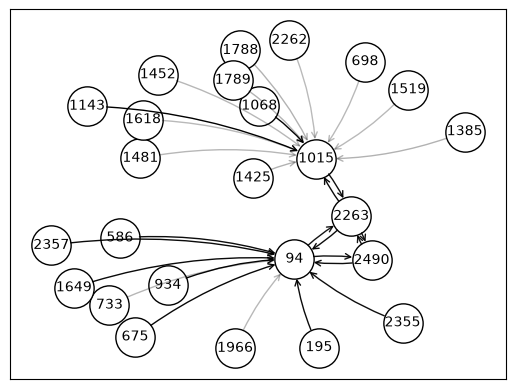

In [29]:
for group_name, group_df in examples.items():

    for _, row in group_df.iterrows():

        node_idx = int(row["node"])
        explanation = explanations[node_idx]
        true = int(row['true_class'])
        pred = int(row['predicted_class'])

        print(
            f"\n{group_name}"
            f"\nNode: {node_idx}"
            f"\nTrue class: {label_dict[true]}"
            f"\nPredicted class: {label_dict[pred]}"
            f"\nConfidence: {row['confidence']:.3f}"
        )

        # Feature importance
        chart = xai.plot_feature_importance(
            explanation,
            top_k=10,
            title=f"{group_name} — Node {node_idx}",
        )

        display(chart)

        # Explanatory subgraph
        explanation.visualize_graph()
